# Generate cell-specific GRNs for human pancreas with scCAFM SFM

This tutorial shows how to infer cell-specific gene regulatory networks (GRNs) from a human pancreas single-cell dataset. The workflow keeps a few medium-sized objects visible so it is easy to understand what is happening: the preprocessed AnnData, the dense forward GRN tensor, and a minimal exported edge table.

The final edge table is intentionally compact. It contains only the cell index and TF-to-target gene names, which makes it easier to inspect, save, and reuse in downstream analysis.


## 1. Environment

Run this notebook from the scCAFM repository root, or from `docs/`. The first cell resolves the repository root and adds it to `sys.path` so the local `src` package can be imported directly.


In [1]:
from pathlib import Path
import sys

start = Path.cwd().resolve()
repo_root = start if (start / "src").exists() else start.parent
if not (repo_root / "src").exists():
    raise RuntimeError("Run this notebook from the scCAFM repository root or docs/.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import scanpy as sc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"

from src.inference import grn

print(f"Repository root: {repo_root}")


Repository root: /data1021/xukaichen/scCAFM


## 2. Configure inputs

The pancreas dataset path is the runnable default for this tutorial. `n_top_genes` controls how many HVGs are kept after preprocessing, while `max_length` controls the tokenizer sequence capacity and should be larger than the selected gene count.

`top_k_per_cell` controls how many high-ranking TF-to-target edges are exported for each cell. The saved CSV stays minimal even though scores are used internally for ranking.


In [2]:
input_h5ad = Path("/data1021/xukaichen/data/GRN/datasets/pancreas.h5ad")
output_csv = repo_root / "results" / "pancreas_cell_specific_sfm_grn_edges.csv"

model_source = repo_root / "assets"
checkpoint_path = None

batch_size = 64
max_length = 1024
n_top_genes = 1000
top_k_per_cell = 1000
score_threshold = None

top_n_sources = 20
top_n_targets = 20
heatmap_top_n_sources = 15
heatmap_top_n_targets = 15

gene_key = None
species_key = "species"
disease_key = "disease"

print(f"Input: {input_h5ad}")
print(f"Output: {output_csv}")


Input: /data1021/xukaichen/data/GRN/datasets/pancreas.h5ad
Output: /data1021/xukaichen/scCAFM/results/pancreas_cell_specific_sfm_grn_edges.csv


## 3. Preprocess AnnData

This tutorial uses normal HVG preprocessing: one fixed active gene universe is selected for all cells. TF genes are not forced to remain before HVG selection, so the active genes are determined by the same standard HVG rule used for expression preprocessing.

The returned `run` object keeps the processed AnnData, tokenizer metadata, dataloader, and model together. For reading the tutorial, the most important object here is `processed_adata`, because its observations define the cell order used later in `forward_results` and `edges_df`.


In [3]:
run = grn.prepare(
    input_h5ad=input_h5ad,
    mode=grn.PreprocessMode.NORMAL_HVG,
    model_source=model_source,
    checkpoint_path=checkpoint_path,
    config_path=repo_root / "configs" / "eval_grn.yaml",
    batch_size=batch_size,
    max_length=max_length,
    n_top_genes=n_top_genes,
    gene_key=gene_key,
    species_key=species_key,
    disease_key=disease_key,
)

processed_adata = run.adata
print(f"Raw shape: {run.raw_adata.shape}")
print(f"Processed shape: {processed_adata.shape}")
processed_adata


Raw shape: (3696, 27998)
Processed shape: (3696, 1000)


AnnData object with n_obs × n_vars = 3696 × 1000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'species', 'disease', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'highly_variable_genes', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

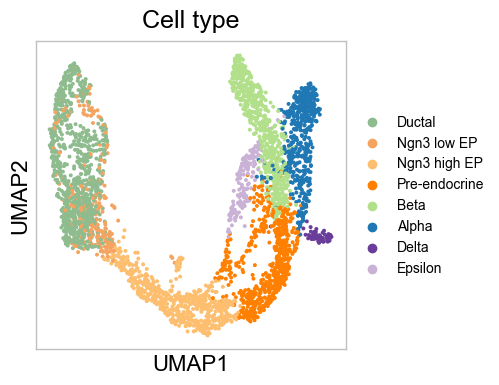

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

ax = sc.pl.umap(
    processed_adata,
    color="clusters",
    ax=ax,
    show=False
)

ax.set_xlabel("UMAP1", fontsize=16)
ax.set_ylabel("UMAP2", fontsize=16)
ax.set_title("Cell type", fontsize=18, pad=10)

for spine in ax.spines.values():
    spine.set_color("#C0C0C0")
    spine.set_linewidth(1)

plt.show(fig)


## 4. Collect forward results

`forward_results` is a dense NumPy array with shape `(cell, gene, gene)` after padding gene slots are removed. For example, if the processed dataset has 3,696 cells and 1,000 active genes, the expected shape is `(3696, 1000, 1000)`.

The second and third axes use the same active gene order. Each cell therefore has one predicted GRN matrix over the active gene universe.


In [5]:
forward_results = grn.predict(run)

print(f"forward_results shape: {forward_results.shape}")
print(f"forward_results dtype: {forward_results.dtype}")


forward_results shape: (3696, 1000, 1000)
forward_results dtype: float32


## 5. Build edge table

The dense tensor is useful as a model output, but it is too large for a readable tutorial table. Here we convert it into a compact edge table by keeping the top TF-to-active-gene predictions for each cell.

The exported table records only `cell_index`, `source_gene`, and `target_gene`. Scores and token IDs are used internally for filtering and ranking, but are not saved.


In [6]:
edges_df = grn.edges(
    run,
    forward_results,
    output_csv=output_csv,
    top_k_per_cell=top_k_per_cell,
    score_threshold=score_threshold,
)

print(f"Saved {len(edges_df):,} edges to {output_csv}")
print(f"Cells with exported edges: {edges_df['cell_index'].nunique():,}")
edges_df.head()


Saved 3,696,000 edges to /data1021/xukaichen/scCAFM/results/pancreas_cell_specific_sfm_grn_edges.csv
Cells with exported edges: 3,696


,cell_index,source_gene,target_gene
0,0,RCOR2,TPBG
1,0,REST,IGSF8
2,0,LMO1,TPBG
3,0,REST,TPBG
4,0,LMO1,GPC4


## 6. Visualize GRN edge properties

These figures summarize simple properties of the exported cell-specific GRNs without embedding the full dense GRN tensor.

The bar plots show which source TFs and target genes appear most often across exported edges. The heatmap shows frequent TF-target combinations among the most common sources and targets, which is a quick way to inspect repeated regulatory patterns.


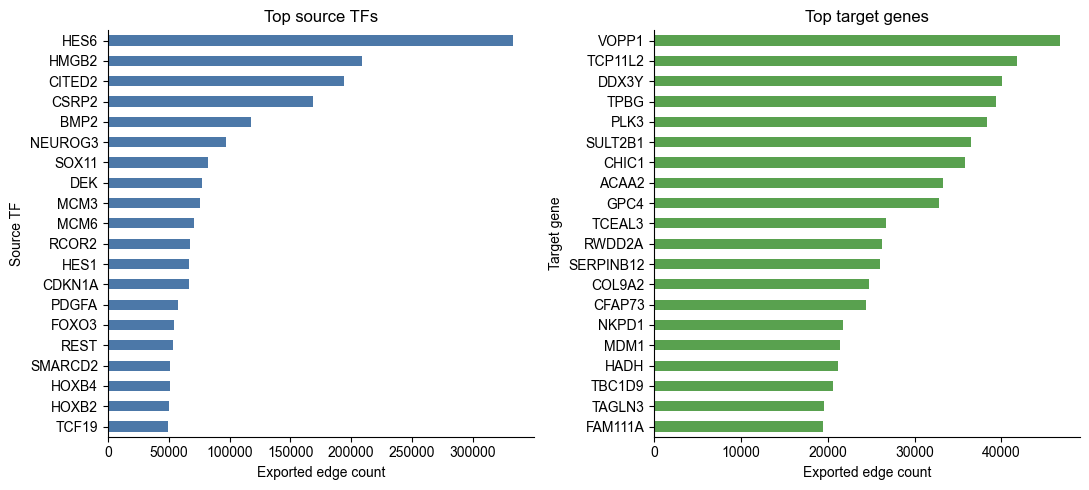

In [7]:
if edges_df.empty:
    print("No edges were exported. Increase `top_k_per_cell` or relax `score_threshold`.")
else:
    source_counts = edges_df["source_gene"].value_counts().head(top_n_sources).sort_values()
    target_counts = edges_df["target_gene"].value_counts().head(top_n_targets).sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    source_counts.plot.barh(ax=axes[0], color="#4C78A8")
    axes[0].set_xlabel("Exported edge count")
    axes[0].set_ylabel("Source TF")
    axes[0].set_title("Top source TFs")

    target_counts.plot.barh(ax=axes[1], color="#59A14F")
    axes[1].set_xlabel("Exported edge count")
    axes[1].set_ylabel("Target gene")
    axes[1].set_title("Top target genes")

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()


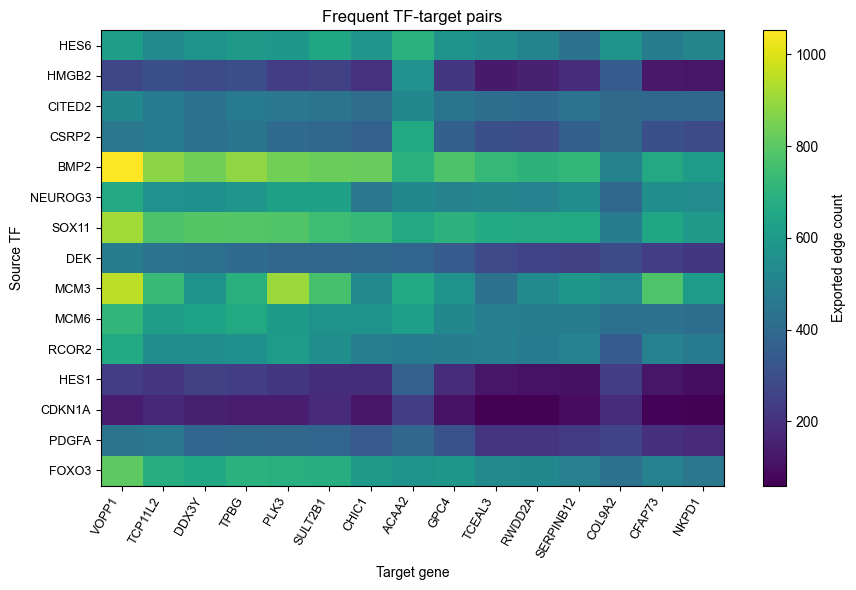

In [8]:
if edges_df.empty:
    print("No edges were exported. Increase `top_k_per_cell` or relax `score_threshold`.")
else:
    heatmap_sources = edges_df["source_gene"].value_counts().head(heatmap_top_n_sources).index
    heatmap_targets = edges_df["target_gene"].value_counts().head(heatmap_top_n_targets).index
    heatmap_df = (
        edges_df[
            edges_df["source_gene"].isin(heatmap_sources)
            & edges_df["target_gene"].isin(heatmap_targets)
        ]
        .groupby(["source_gene", "target_gene"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=heatmap_sources, columns=heatmap_targets, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    image = ax.imshow(heatmap_df.values, aspect="auto", cmap="viridis")

    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns, rotation=60, ha="right", fontsize=9)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index, fontsize=9)
    ax.set_xlabel("Target gene")
    ax.set_ylabel("Source TF")
    ax.set_title("Frequent TF-target pairs")

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("Exported edge count")

    fig.tight_layout()
    plt.show()


## 7. Notes

- `cell_index` is the row index after preprocessing, so it matches `processed_adata.obs`.
- Sources are restricted to TFs; targets are all active processed genes.
- `forward_results` contains all processed cells, so it can be reused for later predicted-result inspection.
- The result figures summarize exported edge frequencies rather than embedding the full dense GRN.
- If `top_k_per_cell` is fixed, per-cell edge counts may be similar by design; source and target frequencies are usually more informative in this tutorial.
